# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [2]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install scipy
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install --upgrade pandas   # if an older pandas is already installed

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [4]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int32         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int32(1), object(1)
memory usage: 7.0+ KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [5]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.


===== date =====


,count,proportion_%
date,,
2021-02-01,1,0.62
2021-02-02,1,0.62
2021-02-03,1,0.62
2021-02-04,1,0.62
2021-02-05,1,0.62
...,...,...
2021-07-06,1,0.62
2021-07-07,1,0.62
2021-07-08,1,0.62



===== region =====


,count,proportion_%
region,,
West,47,29.38
East,42,26.25
South,36,22.50
North,35,21.88


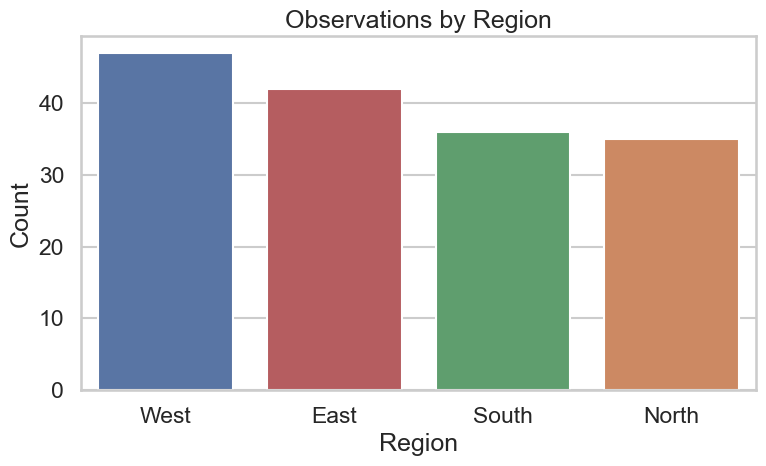

In [6]:
# Value counts for every non-numeric column
non_numeric_cols = df.select_dtypes(
    exclude='number'
).columns

for col in non_numeric_cols:

    print(f"\n===== {col} =====")

    counts = df[col].value_counts(
        dropna=False
    )

    proportions = (
        df[col]
        .value_counts(
            dropna=False,
            normalize=True
        )
        .mul(100)
        .round(2)
    )

    profile = pd.DataFrame({
        'count': counts,
        'proportion_%': proportions
    })

    display(profile)


# Plot a categorical column
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='region',
    hue='region',
    order=df['region'].value_counts().index,
    legend=False
)

plt.title('Observations by Region')
plt.xlabel('Region')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 3) Distributions — two worked examples below; add at least one more

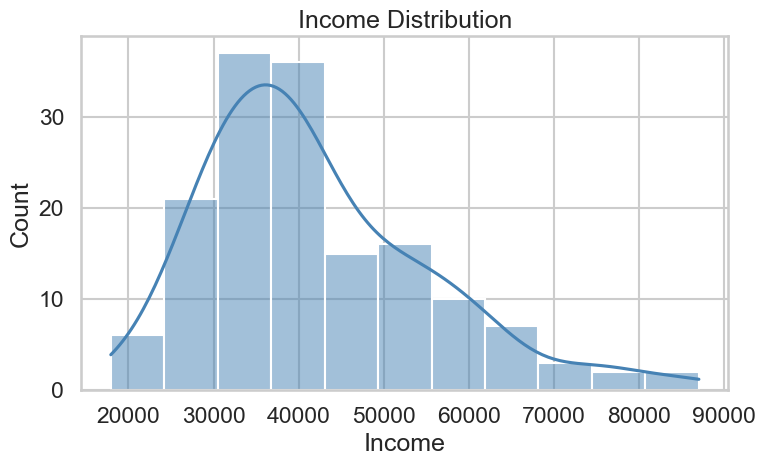

In [8]:
# Distribution 1 — Income
plt.figure(figsize=(8, 5))

sns.histplot(
    df['income'],
    kde=True,
    color='steelblue'
)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.tight_layout()
plt.show()

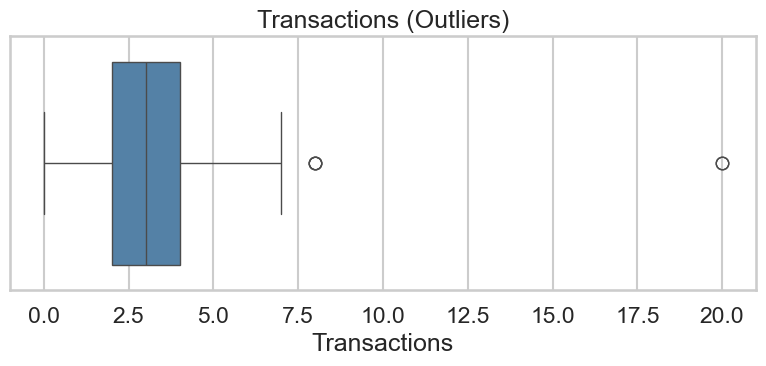

In [9]:
# Distribution 2 — Transactions
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['transactions'],
    color='steelblue'
)

plt.title('Transactions (Outliers)')
plt.xlabel('Transactions')

plt.tight_layout()
plt.show()

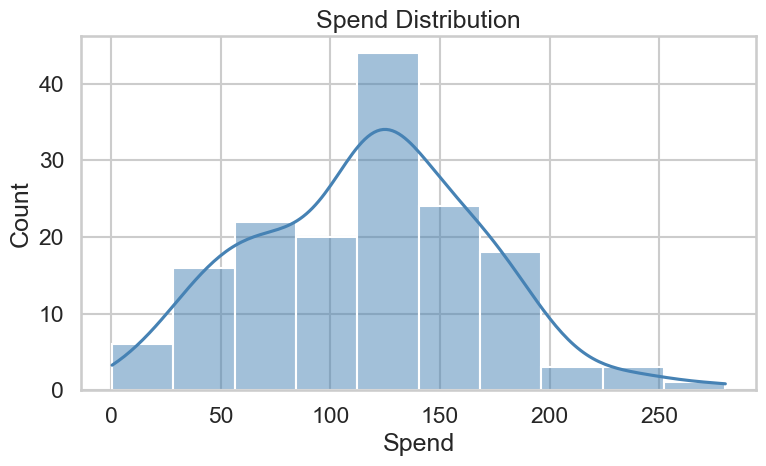

In [10]:
# Distribution 3 — Spend
plt.figure(figsize=(8, 5))

sns.histplot(
    df['spend'],
    kde=True,
    color='steelblue'
)

plt.title('Spend Distribution')
plt.xlabel('Spend')

plt.tight_layout()
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

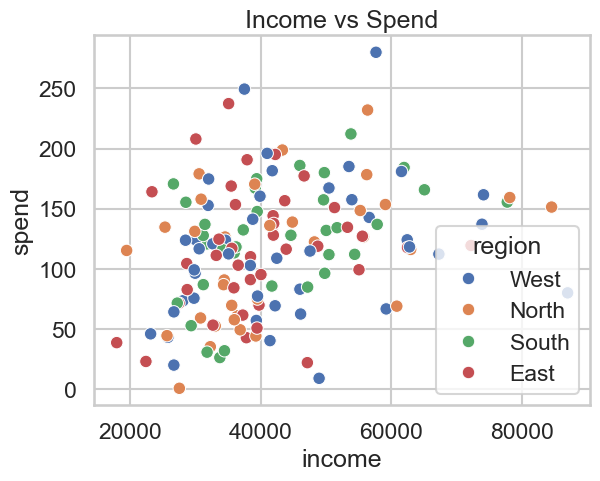

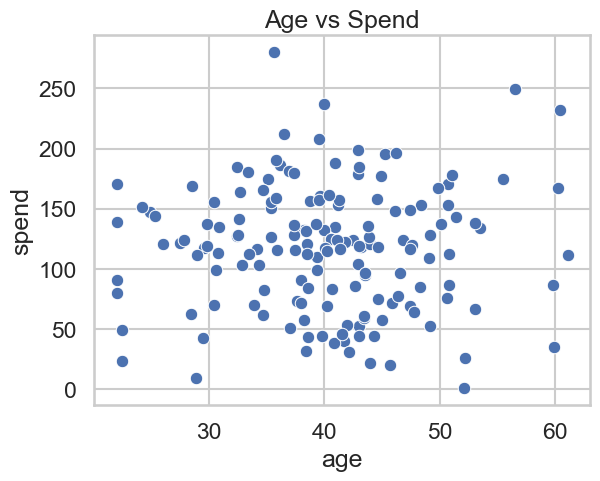

In [11]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

In [12]:
# Sort by date before time-series analysis
df_time = df.sort_values('date').copy()

df_time = df_time.set_index('date')

expected_dates = pd.date_range(
    df_time.index.min(),
    df_time.index.max(),
    freq='D'
)

missing_dates = expected_dates.difference(
    df_time.index
)

print(
    f"Number of missing dates: "
    f"{len(missing_dates)}"
)

if len(missing_dates) > 0:
    print(
        "Missing dates:",
        missing_dates.tolist()
    )

Number of missing dates: 0


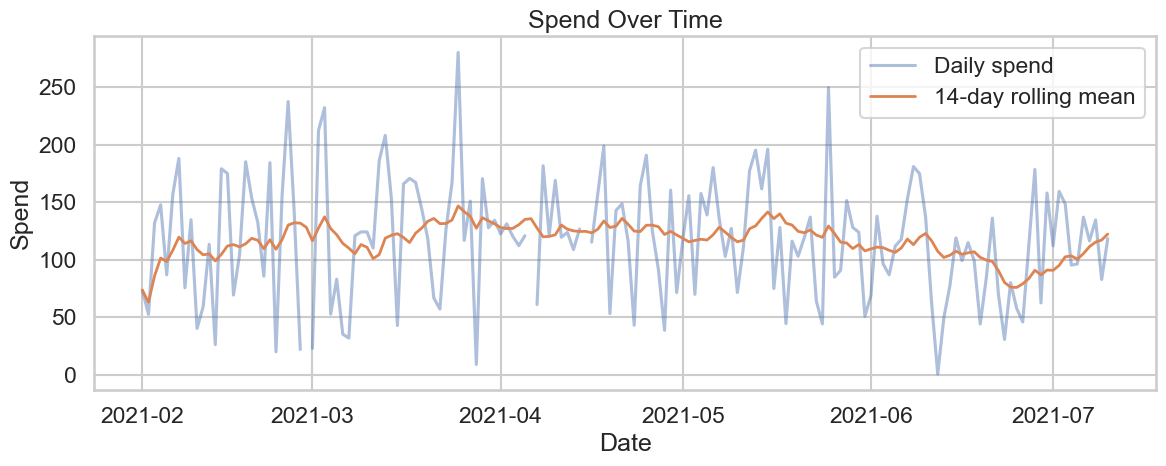

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_time.index,
    df_time['spend'],
    alpha=0.45,
    label='Daily spend'
)

plt.plot(
    df_time.index,
    df_time['spend']
        .rolling(
            window=14,
            min_periods=1
        )
        .mean(),
    linewidth=2,
    label='14-day rolling mean'
)

plt.title('Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Spend')

plt.legend()

plt.tight_layout()
plt.show()

### Time-series interpretation

The dates are continuous with no missing daily observations, so rolling-window features can be constructed without hidden calendar gaps.

Daily spend is noisy, and the 14-day rolling mean moves up and down rather than showing a stable long-run upward trend or a clear repeating seasonal cycle. There is also no obvious permanent level shift in this synthetic sample.

For Stage 09, lag and rolling features may still capture short-term local variation, but they should be validated rather than assumed useful.

For Stage 10b, the data should remain sorted by date and be split chronologically rather than randomly to avoid leakage from future observations.

## 5) (Optional) Correlation matrix

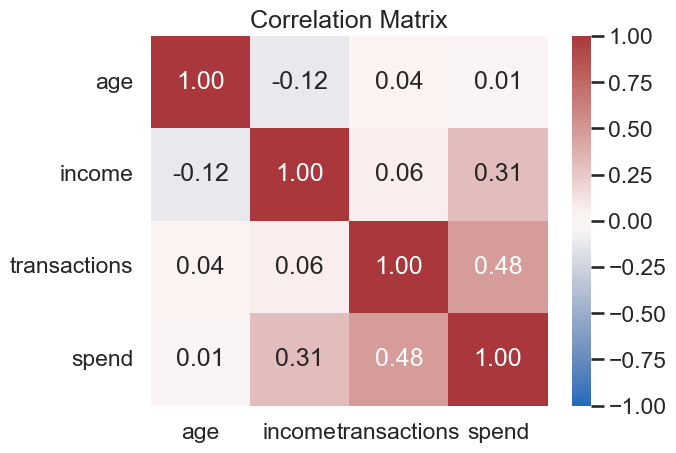

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [14]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [15]:
from src.eda import eda_summary

summary = eda_summary(df)

summary

,column,dtype,missing_count,missing_pct,n_unique,top_value,top_share,mean,std,min,max
0,date,datetime64[ns],0,0.00,160,2021-02-01 00:00:00,0.006,NaN,NaN,NaN,NaN
1,region,object,0,0.00,4,West,0.294,NaN,NaN,NaN,NaN
2,age,float64,0,0.00,122,NaN,NaN,40.018750,8.458676,22.00,61.10
3,income,float64,5,3.12,155,NaN,NaN,41983.866323,13262.457038,17928.80,87052.40
4,transactions,int32,0,0.00,10,NaN,NaN,3.237500,2.585610,0.00,20.00
5,spend,float64,3,1.88,156,NaN,NaN,117.291592,51.768645,0.54,280.05


## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)


### Top 3 insights

1. **Missingness is limited but real.** `income` has 5 missing values and `spend` has 3. These rows need an explicit preprocessing decision before modeling so that missing values are not handled inconsistently across train/test data.

2. **Transactions contains strong outliers and right skew.** The maximum transaction count is far above the typical range, and its skewness is much larger than the other numeric variables. These observations should be checked and possibly capped, transformed, or handled with a robust model rather than automatically deleted.

3. **Spend is more strongly related to transactions than to age.** The relationship plots and correlation matrix suggest that transactions carries more predictive structure for spend, while age has little visible linear relationship. Income has a weaker but still positive relationship with spend.

### Assumptions & risks

- The synthetic data is only a stand-in for the real project dataset, so these patterns should not be treated as real-world conclusions.
- Missing values are assumed to be data-quality issues rather than meaningful missingness; this must be checked with the real dataset.
- The extreme transaction values were deliberately injected by the generator. In real data, apparent outliers could be valid high-activity cases and should be investigated before removal.
- No clear seasonality or persistent level shift appears in this short synthetic daily sample. A longer real time series may reveal patterns that are not visible here.

### Implications for next step

Before Stage 09, I would:

1. Define a reproducible missing-value strategy for `income` and `spend`.
2. Create robust handling or transformations for the highly skewed/outlier-prone `transactions` variable.
3. Preserve chronological ordering and consider lag/rolling features for time-based modeling.
4. Prioritize transaction and income features over age unless later analysis shows nonlinear value.

Before Stage 10b, I would use a chronological train/validation/test split so future information cannot leak into earlier observations.